# Demonstracija Mapper algoritma

Ovaj notebook prikazuje osnovnu ideju Mapper algoritma iz topološke analize podataka. Mapper je metoda koja od skupa tačaka pravi graf ili simplicijalni kompleks koji opisuje globalni oblik podataka.

Implementacija je zasnovana na radu:

**G. Singh, F. Mémoli, G. Carlsson**,  
*Topological Methods for the Analysis of High Dimensional Data Sets and 3D Object Recognition*,  
Eurographics Symposium on Point-Based Graphics, 2007.

Osnovna ideja je sledeća. Imamo skup podataka `X`, biramo filter funkciju `f: X -> R^d`, pokrivamo sliku funkcije `f(X)` preklapajućim skupovima, vraćamo se u originalni prostor preko inverzne slike, zatim u svakom delu radimo klasterovanje. Svaki dobijeni klaster postaje čvor Mapper grafa, a dva čvora povezujemo ako njihovi klasteri dele bar jednu originalnu tačku.

U notebook-u ćemo prvo raditi sa jednostavnim primerom noisy circle, a zatim ćemo pogledati različite filtere, različite cover-e, torus i 3D objekte.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

import mapper as mp

%matplotlib inline
%config InlineBackend.close_figures = True
plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(0)

## 1. Skup podataka: noisy circle

Prvi primer je skup tačaka koji približno leži na kružnici. U idealnom slučaju kružnica ima jednu povezanu komponentu i jednu rupu. Zato je ovo dobar početni primer za Mapper, jer možemo vizuelno da proverimo da li dobijeni graf zaista hvata kružnu strukturu.

Tačkama dodajemo mali šum, pa podaci nisu savršena kružnica, već oblak tačaka oko kružnice. Filter funkcija koju prvo koristimo je visina, odnosno y-koordinata:

`f(x, y) = y`

Na slici su tačke obojene prema vrednosti filter funkcije. Donje tačke imaju manje vrednosti filtera, a gornje tačke veće vrednosti.

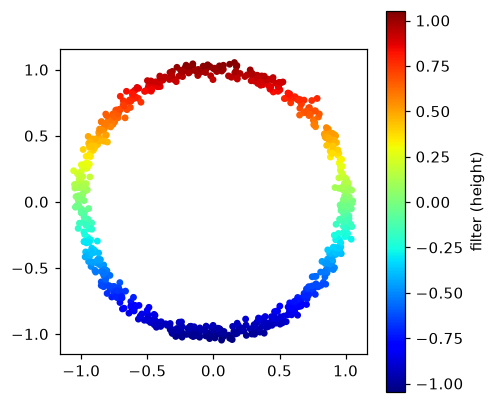

In [12]:
# noisy circle
n = 800
t = rng.uniform(0, 2*np.pi, n)
X = np.column_stack([np.cos(t), np.sin(t)]) + rng.normal(0, 0.03, (n, 2))

p = X[np.argmin(X[:, 0])]                   # leftmost point (kept for later cells)
f = X[:, 1]                                 # the filter values: height  f(x)=y

fig, ax = plt.subplots(figsize=(4.5, 4.5))
sc = ax.scatter(X[:, 0], X[:, 1], c=f, cmap="jet", s=12)
plt.colorbar(sc, label="filter (height)")
ax.set_aspect("equal")

## 2. Cover slike filter funkcije

Sada ne posmatramo direktno ceo skup tačaka, već posmatramo vrednosti filter funkcije `f(X)`. Pošto je u ovom primeru filter jednodimenzionalan, slika filter funkcije je interval realnih brojeva.

Taj interval pokrivamo manjim preklapajućim intervalima. Ovo je korak koji se u Mapper algoritmu zove cover.

Preklapanje je veoma važno. Ako se intervali ne bi preklapali, delovi podataka bi bili potpuno odvojeni i teško bismo mogli da dobijemo povezan globalni graf. Zbog preklapanja ista originalna tačka može pripadati u više cover elemenata, što kasnije omogućava povezivanje čvorova u Mapper grafu.

interval bounds (left, right):
   [-1.099 -0.731]
   [-0.836 -0.469]
   [-0.574 -0.206]
   [-0.311  0.056]
   [-0.049  0.319]
   [0.214 0.581]
   [0.476 0.844]
   [0.739 1.106]


Text(0.5, 1.0, 'Overlapping intervals covering the range of f')

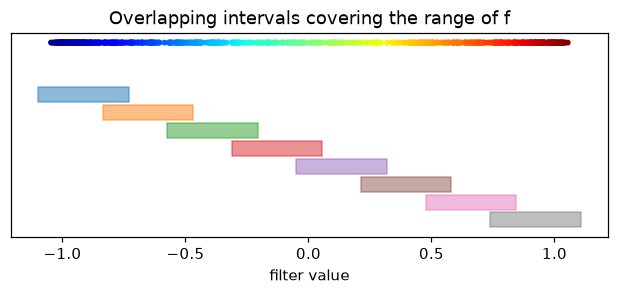

In [13]:
cover = mp.IntervalCover(n_intervals=8, overlap=0.4).fit(f.reshape(-1, 1))
bounds = cover.bounds_
print("interval bounds (left, right):")
for b in bounds: print("  ", np.round(b, 3))

fig, ax = plt.subplots(figsize=(7, 2.4))
ax.scatter(f, np.zeros_like(f), c=f, cmap="jet", s=8)
for i, (lo, hi) in enumerate(bounds):
    ax.add_patch(plt.Rectangle((lo, -0.4 - 0.12*i), hi-lo, 0.1,
                 alpha=0.5, color=plt.cm.tab10(i)))
ax.set_yticks([]); ax.set_xlabel("filter value")
ax.set_title("Overlapping intervals covering the range of f")

## 3. Inverzna slika cover elemenata i lokalno klasterovanje

Za svaki interval iz cover-a gledamo koje originalne tačke imaju filter vrednost unutar tog intervala. Drugim rečima, za interval `U` posmatramo skup:

`f^{-1}(U)`

To znači da se iz prostora filter vrednosti vraćamo nazad u originalni skup tačaka.

Zatim se unutar svakog takvog dela radi klasterovanje. U ovom notebook-u koristi se DBSCAN, koji grupiše tačke prema njihovoj međusobnoj udaljenosti. Ideja je da svaki lokalni klaster predstavlja jedan lokalni deo oblika podataka.

Na slikama ispod svaki mali panel prikazuje tačke koje pripadaju jednom intervalu cover-a. Pošto se intervali preklapaju, neke tačke se mogu pojaviti u više panela.

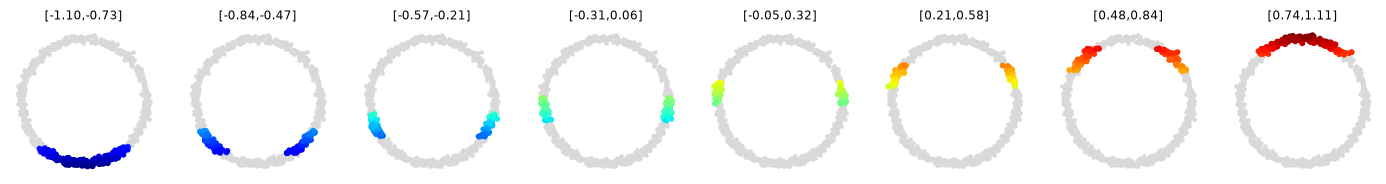

In [14]:
# Pull back intervals and cluster each window
windows = cover.assign(f.reshape(-1, 1))
D = mp.euclidean_distances(X)
clusterer = mp.dbscan(eps=0.25, min_samples=5) #DBSCAN worked better for us

fig, axes = plt.subplots(1, len(windows), figsize=(2.0*len(windows), 2.2))
for ax, w, (lo, hi) in zip(axes, windows, bounds):
    ax.scatter(X[:, 0], X[:, 1], c="0.85", s=4)
    labels = clusterer(w, D)
    for L in np.unique(labels):
        m = w[labels == L]
        ax.scatter(X[m, 0], X[m, 1], c=f[m], cmap="jet",
                   vmin=f.min(), vmax=f.max(), s=8)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"[{lo:.2f},{hi:.2f}]", fontsize=8)

## 4. Konstrukcija Mapper grafa

Sada se od lokalnih klastera konstruiše Mapper graf.

Pravilo je sledeće:

- svaki lokalni klaster postaje jedan čvor grafa;
- dva čvora se povezuju granom ako njihovi klasteri dele bar jednu originalnu tačku.

Do deljenja tačaka dolazi upravo zbog toga što se intervali u cover-u preklapaju. Zato preklapanje nije samo tehnički detalj, nego ključni deo Mapper algoritma.

Na slici ispod graf je prikazan preko originalnog skupa tačaka. Položaj čvora odgovara prosečnom položaju tačaka iz odgovarajućeg klastera, veličina čvora zavisi od broja tačaka u klasteru, a boja označava prosečnu vrednost filter funkcije.

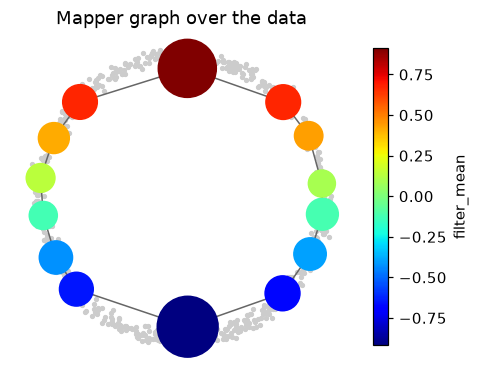

Betti = [1, 1]


In [15]:
# Connect clusters that share points 
m = mp.Mapper(lens=mp.Lens(mp.coordinate(1)),          # height filter f(x)=y
              cover=mp.IntervalCover(8, 0.4),
              clusterer=mp.dbscan(eps=0.25, min_samples=5)).fit(X, D)

fig, ax = plt.subplots(figsize=(5, 5))
mp.overlay_on_points(m, X, ax=ax, color_by="filter_mean", size_scale=8)
ax.set_title("Mapper graph over the data")
plt.show()
print(f"Betti = {list(m.betti_numbers())[:2]}")

## 5. Uticaj filtera, broja intervala i preklapanja-a

Mapper algoritam zavisi od nekoliko izbora. Najvažniji su:

- izbor filter funkcije,
- broj intervala u cover-u,
- veličina preklapanja između intervala,
- metoda klasterovanja i njeni parametri.

Zbog toga isti skup podataka može dati različite Mapper grafove za različite parametre. Interaktivni deo ispod omogućava da menjamo filter, broj intervala i preklapanje i da posmatramo kako se menja dobijeni graf.

In [16]:
import ipywidgets as widgets
from IPython.display import display

Dc = mp.euclidean_distances(X)
filters = {
    "height": mp.coordinate(1),
    "distance from point":  mp.distance_from_point(p),
    "laplacian eigenvector": mp.graph_laplacian(1),
}

filt_dd        = widgets.Dropdown(options=list(filters), value="height", description="filter")
n_slider       = widgets.IntSlider(value=6, min=3, max=20, step=1, continuous_update=False, description="intervals")
overlap_slider = widgets.FloatSlider(value=0.35, min=0.1, max=0.6, step=0.05, continuous_update=False, description="overlap")
out            = widgets.Output()

def explore(change=None):
    out.clear_output(wait=True)
    with out:
        mm = mp.Mapper(mp.Lens(filters[filt_dd.value]),
                       mp.IntervalCover(n_slider.value, overlap_slider.value),
                       mp.dbscan(eps=0.25, min_samples=5)).fit(X, Dc)
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(X[:, 0], X[:, 1], c="0.85", s=5)
        mp.overlay_on_points(mm, X, ax=ax, color_by="filter_mean", size_scale=8)
        ax.set_aspect("equal"); ax.axis("off")
        ax.set_title(f"{filt_dd.value}  —  Betti {list(mm.betti_numbers())[:2]}")
        plt.show()
        plt.close(fig)

filt_dd.observe(explore, names="value")
n_slider.observe(explore, names="value")
overlap_slider.observe(explore, names="value")

explore()
display(widgets.VBox([filt_dd, n_slider, overlap_slider, out]))

## 6. Dvodimenzionalni cover

Do sada je filter bio jednodimenzionalan, pa smo koristili intervale. Međutim, Mapper može da koristi i višedimenzionalne filtere.

Ako je filter oblika `f: X -> R^2`, onda sliku filtera ne pokrivamo intervalima, već dvodimenzionalnim oblastima. U ovoj implementaciji postoje pravougaoni i heksagonalni cover.

U ovom primeru generišemo jednostavan dvodimenzionalni oblak tačaka i prikazujemo kako izgledaju različiti cover elementi. Ovo nije još potpuna Mapper konstrukcija, već ilustracija kako se prostor filter vrednosti može podeliti na preklapajuće dvodimenzionalne oblasti.

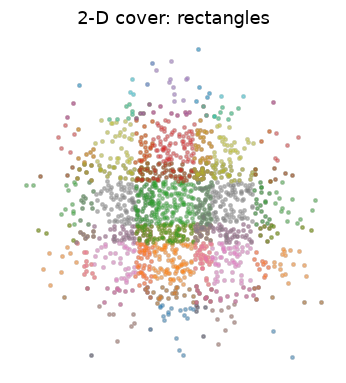

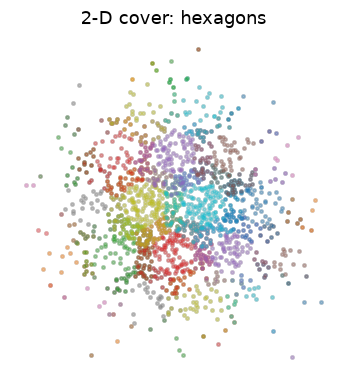

In [39]:
blob = rng.normal(0, 1, (1500, 2))
for Cover, name in [(mp.RectangleCover((5,5), 0.3), "rectangles"),
                    (mp.HexagonCover(5, 0.3), "hexagons")]:
    Cover.fit(blob); wins = Cover.assign(blob)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(blob[:,0], blob[:,1], c="0.85", s=5)
    for w in wins[:60]:
        if len(w): ax.scatter(blob[w,0], blob[w,1], s=4, alpha=0.3)
    ax.set_aspect("equal"); ax.set_title(f"2-D cover: {name}"); ax.axis("off")
    plt.show()

## 7. Primer torusa i Laplasov filter

Sledeći primer je torus. Torus je površ koja topološki ima jednu povezanu komponentu, dve nezavisne jednodimenzionalne rupe i jednu dvodimenzionalnu šupljinu. Zato su njegovi Betti brojevi:

`[1, 2, 1]`

To znači:

- `β0 = 1`, torus ima jednu povezanu komponentu;
- `β1 = 2`, torus ima dve nezavisne petlje;
- `β2 = 1`, torus ima jednu dvodimenzionalnu šupljinu.

U kodu se prvo generiše torus u prostoru, zatim se ugrađuje u višu dimenziju pomoću slučajne rotacije. Ovo imitira situaciju kada podaci žive u višedimenzionalnom prostoru, ali imaju jednostavnu skrivenu topološku strukturu.

Koristi se i graph Laplacian filter. On se često koristi u topološkoj analizi podataka jer njegove sopstvene funkcije mogu da otkriju globalnu geometrijsku strukturu podataka.

Text(0.5, 0.92, 'torus coloured by Laplacian eigenfunction 1')

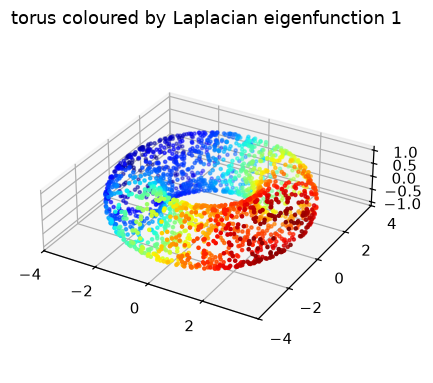

In [40]:
def make_torus(n=2000, R=2.5, r=1.0, seed=0):
    rr = np.random.default_rng(seed)
    u = rr.uniform(0, 2*np.pi, n); v = rr.uniform(0, 2*np.pi, n)
    X3 = np.column_stack([(R+r*np.cos(v))*np.cos(u), (R+r*np.cos(v))*np.sin(u), r*np.sin(v)])
    return X3, u, v

X3, u, v = make_torus()
# embed in R^5 with a random rotation 
Xt = np.hstack([X3, np.zeros((len(X3), 2))])
Q, _ = np.linalg.qr(np.random.default_rng(1).normal(size=(5,5)))
Xt = Xt @ Q
Dt = mp.euclidean_distances(Xt)

evecs = mp.graph_laplacian(2)(Xt, Dt)          # first 2 non-trivial eigenfunctions
fig = plt.figure(figsize=(9,4))
a0 = fig.add_subplot(1,1,1, projection="3d")
a0.set_box_aspect(np.ptp(X3, axis=0))
a0.scatter(X3[:,0], X3[:,1], X3[:,2], c=evecs[:,0], cmap="jet", s=4)
a0.set_title("torus coloured by Laplacian eigenfunction 1")

## 8. Mapper kompleks torusa

Za torus se sada konstruiše Mapper kompleks. Ovde se koriste dve unapred poznate ugaone koordinate torusa, `u` i `v`, kao filter funkcije. Pošto su to kružne koordinate, koristi se circular cover.

Za razliku od prethodnog primera sa noisy circle, ovde nije dovoljno posmatrati samo graf, jer torus ima i dvodimenzionalnu topološku strukturu. Zato se Mapper rezultat pretvara u simplicijalni kompleks i računaju se Betti brojevi.

Ako Mapper dobro uhvati strukturu torusa, očekujemo Betti brojeve približno jednake:

`[1, 2, 1]`

To odgovara topologiji torusa.

Betti numbers of the Mapper complex: [1, 2, 1]  (torus = [1, 2, 1])


Text(0.5, 0.92, 'Mapper torus (abstract graph) — Betti [1, 2, 1]')

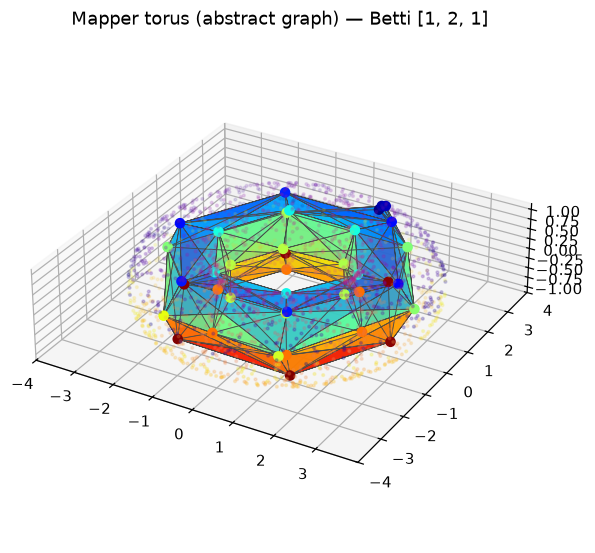

In [41]:
mt = mp.Mapper(mp.Lens([mp.precomputed(u), mp.precomputed(v)]),
               mp.CircularCover(n_per_axis=(6, 6), overlap=0.5),
               mp.dbscan(eps=0.6, min_samples=5)).fit(Xt, Dt)
betti = list(mt.betti_numbers())[:3]
print("Betti numbers of the Mapper complex:", betti, " (torus = [1, 2, 1])")
assert betti == [1, 2, 1]

# draw the complex embedded in 3-D, nodes fixed at cluster centers
ax = mp.plot_complex_3d(mt, X3, color_by=1)   # colour by minor angle v
ax.scatter(X3[:, 0], X3[:, 1], X3[:, 2], c=v, cmap="plasma", s=3, alpha=0.5, zorder=0)
ax.set_title(f"Mapper torus (abstract graph) — Betti {betti}")

## 9. Mapper na 3D oblicima

Poslednji deo notebook-a je namenjen radu sa 3D objektima, na primer sa mesh fajlovima životinja ili drugih oblika.

Ideja je da se 3D objekat posmatra kao oblak tačaka, odnosno skup temena mesh-a. Zatim se na taj skup tačaka primenjuje Mapper sa različitim filterima, kao što su eccentricity i graph Laplacian.

In [42]:
import glob, os

def load_points(path, n_sample=5000):
    import trimesh
    mesh = trimesh.load(path, force="mesh")
    P = np.asarray(mesh.vertices)
    if len(P) > n_sample:
        P = P[np.random.default_rng(0).choice(len(P), n_sample, replace=False)]
    return P

files = sorted(glob.glob("data/elephant*.*"))
if len(files) >= 2:
    poses = [load_points(files[0]), load_points(files[1])]
    print("loaded:", files[:2])
else:
    print("no files in data/")

loaded: ['data/elephant1.obj', 'data/elephant2.obj']



Prvo se 3D tačke projektuju u 2D pomoću PCA samo radi vizuelizacije. Sama Mapper konstrukcija i dalje koristi originalne tačke i njihova međusobna rastojanja.

U ovom delu se prikazuju dva pristupa:

1. Mapper sa dvodimenzionalnim filterom koji kombinuje eccentricity i graph Laplacian.
2. Mapper sa jednodimenzionalnim filterom zasnovanim na graph Laplacian-u.

Eccentricity meri koliko je jedna tačka u proseku udaljena od ostalih tačaka. Graph Laplacian filter pokušava da uhvati globalnu strukturu oblika. Kombinovanjem ovih filtera mogu se dobiti grafovi koji naglašavaju različite delove 3D objekta.

Ovaj deo je koristan za povezivanje Mapper algoritma sa primenom iz originalnog rada, gde se topološke metode koriste za analizu visokodimenzionalnih skupova podataka i 3D prepoznavanje objekata.

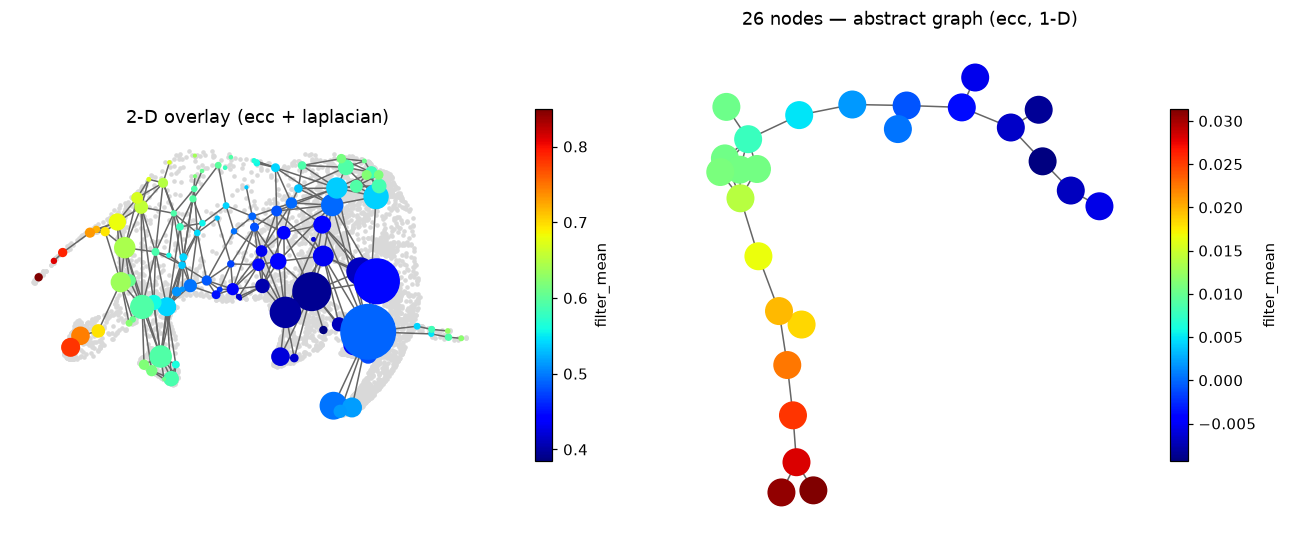

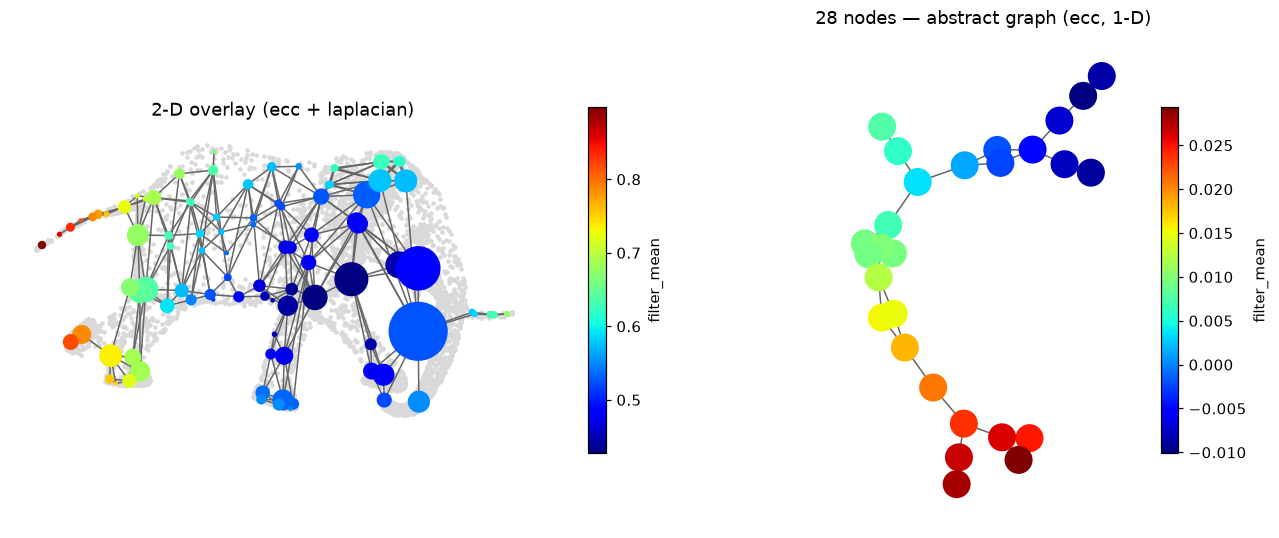

In [ ]:
def to_2d(P):
    if P.shape[1] == 2:
        return P
    from sklearn.decomposition import PCA
    return PCA(n_components=2).fit_transform(P)

for P in poses:
    D = mp.euclidean_distances(P)
    P2 = to_2d(P)

    # 2-D lens: eccentricity + laplacian eigenvector, rectangle cover
    m2d = mp.Mapper(mp.Lens([mp.eccentricity(1.0), mp.graph_laplacian(1)]),
                    mp.RectangleCover((10, 10), 0.4),
                    mp.single_linkage(),
                    min_cluster_size=3).fit(P, D)

    # 1-D lens: eccentricity only, interval cover
    m1d = mp.Mapper(mp.Lens([mp.graph_laplacian(1)]),
                    mp.IntervalCover(15, 0.4),
                    mp.single_linkage(),
                    min_cluster_size=3).fit(P, D)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    mp.overlay_on_points(m2d, P2, ax=ax1, point_color="0.85", point_size=4,
                         color_by="filter_mean", size_scale=1)
    ax1.set_aspect("equal"); ax1.axis("off")
    ax1.set_title(f"2-D overlay (ecc + laplacian)")

    mp.plot_graph(m1d, ax=ax2, color_by="filter_mean", size_scale=None)
    ax2.set_title("Abstract graph (ecc, 1-D)")
    plt.tight_layout()
    plt.show()

## Zaključak

Ovaj notebook pokazuje kako Mapper algoritam pravi topološki sažetak skupa podataka.

Glavni koraci su:

1. izbor filter funkcije,
2. pravljenje cover-a slike filter funkcije,
3. vraćanje cover elemenata u originalni prostor preko inverzne slike,
4. lokalno klasterovanje,
5. konstrukcija grafa ili simplicijalnog kompleksa,
6. interpretacija dobijene topološke strukture.

Na jednostavnom primeru kružnice Mapper graf hvata kružnu strukturu podataka. Na primeru torusa Mapper kompleks može da rekonstruiše očekivane Betti brojeve `[1, 2, 1]`. Time se vidi osnovna svrha Mapper algoritma: da od komplikovanog skupa tačaka napravi manji i razumljiviji objekat koji čuva važne informacije o obliku podataka.

Važno je naglasiti da Mapper rezultat zavisi od izabranih parametara. Zato se u praksi Mapper često koristi interaktivno, uz isprobavanje različitih filter funkcija, cover-a i metoda klasterovanja.